In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import torch
import os

from prob_path_function import (
    sample_uniform_counts,
    binBridge_sample_xt,
    dirBridge_sample_xt,
    alpha_max_for_eps,
    build_time_prob_path,
    build_entropy_aligned_path,
)

from count_FM_function_v3 import sample_xt as countfm_sample_xt_torch
from discreteFM_function import kappa_and_deriv, _sample_xt_from_coupling
from tauLDR_function import make_tauldr_schedule, tauldr_sample_xt
from D3PM_function import _alpha_bar_cosine, _alpha_bar_linear_beta, _q_sample_uniform
from SEDD_function import sedd_sigma_and_deriv, _sedd_uniform_forward_sample_xt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(123)
torch.manual_seed(123)

# 1. Config

In [2]:
# same 2D toy target family as simulation_toy_comparison.ipynb

D = 2

# use a support wide enough for this toy
C_max = 100
K = C_max + 1

T_steps = 121
M_samples = 40000

max_xticks = 11

# target parameters copied from simulation_toy_comparison.ipynb
mix_prob = 0.5
k_target = np.array([
    [60.0,  5.0],
    [60.0, 40.0],
])
rate_target = np.array([
    [1.0, 1.0],
    [1.0, 1.0],
])

dims_to_plot = [0, 1]
dim_titles = {
    0: "dim 0",
    1: "dim 1",
}

# 2. Extra Functions

In [3]:
def sample_target_2d(N):
    z = (np.random.rand(N) < mix_prob).astype(int)
    lam = np.random.gamma(shape=k_target[z], scale=1.0 / rate_target[z])
    X = np.random.poisson(lam).astype(int)
    X = np.clip(X, 0, C_max)
    return X

def make_source_sampler_dim(dim_idx):
    def source_sampler_dim(N, C_max):
        # same uniform source for each marginal
        return sample_uniform_counts(N, C_max)
    return source_sampler_dim

def make_target_sampler_dim(dim_idx):
    def target_sampler_dim(N):
        return sample_target_2d(N)[:, dim_idx]
    return target_sampler_dim

In [4]:
def source_sampler(N, C_max):
    return sample_uniform_counts(N, C_max)

def target_sampler(N):
    z = np.random.rand(N) < mix_w
    x = np.empty(N, dtype=int)
    x[z] = np.random.poisson(lam=mix_mu1, size=z.sum())
    x[~z] = np.random.poisson(lam=mix_mu2, size=(~z).sum())
    x = np.clip(x, 0, C_max)
    return x

In [5]:
def samples_to_prob(samples, C_max):
    samples = np.asarray(samples, dtype=int)
    T = samples.shape[0]
    P = np.zeros((T, C_max + 1), dtype=float)
    for i in range(T):
        h = np.bincount(np.clip(samples[i], 0, C_max), minlength=C_max + 1).astype(float)
        P[i] = h / h.sum()
    return P

def plot_prob_grid(P_dict, y_grid_dict, y_label="t", title=None,
                   cmap="Blues", invert_y=False):
    names = list(P_dict.keys())
    n = len(names)

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    vmax = max(P.max() for P in P_dict.values())
    norm = Normalize(vmin=0.0, vmax=vmax)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.4 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    im = None
    for ax, name in zip(axes, names):
        P = P_dict[name]
        y_values = y_grid_dict[name]

        im = ax.imshow(
            P,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            norm=norm,
            interpolation="nearest"
        )

        xticks = np.linspace(0, C_max, min(max_xticks, C_max + 1), dtype=int)
        xticks = np.unique(xticks)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks)

        T = P.shape[0]
        yticks = np.round(np.linspace(0, T - 1, 5)).astype(int)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{float(y_values[j]):.2f}" for j in yticks])

        ax.set_title(name)
        ax.set_xlabel("count")
        ax.set_ylabel(y_label)

        if invert_y:
            ax.invert_yaxis()

    for j in range(len(names), len(axes)):
        axes[j].axis("off")

    fig.subplots_adjust(
        left=0.07,
        right=0.90,
        bottom=0.08,
        top=0.90,
        wspace=0.28,
        hspace=0.28
    )

    cax = fig.add_axes([0.92, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("probability")

    if title is not None:
        fig.suptitle(title, y=0.98, fontsize=13)

    return fig, axes

In [6]:
def countfm_bridge_np(x0, x1, t, **kwargs):
    return binBridge_sample_xt(x0, x1, t)

def dirichlet_bridge_np(x0, x1, t, K, alpha_max, **kwargs):
    return dirBridge_sample_xt(x0, x1, t, K=K, alpha_max=alpha_max)

def discretefm_bridge_np(x0, x1, t, schedule="quadratic", **kwargs):
    x0_t = torch.as_tensor(x0, dtype=torch.long, device=device).view(-1, 1)
    x1_t = torch.as_tensor(x1, dtype=torch.long, device=device).view(-1, 1)
    t_t = torch.full((x0_t.shape[0], 1), float(t), device=device)
    kappa, _ = kappa_and_deriv(t_t, schedule=schedule)
    xt = _sample_xt_from_coupling(x0_t, x1_t, kappa)
    return xt[:, 0].detach().cpu().numpy()

def tauldr_bridge_np(x0, x1, t, C_max, schedule="exp",
                     target_a_bar_1=1e-3, b=10.0, beta0=0.1, beta1=20.0, **kwargs):
    # tauLDR forward law is data -> noise, so use x1 as the data endpoint and 1-t
    _, _, a_bar_fn = make_tauldr_schedule(
        K=C_max + 1,
        schedule=schedule,
        target_a_bar_1=target_a_bar_1,
        b=b,
        beta0=beta0,
        beta1=beta1,
    )
    x1_t = torch.as_tensor(x1, dtype=torch.long, device=device).view(-1, 1)
    t_model = torch.full((x1_t.shape[0], 1), float(1.0 - t), device=device)
    xt = tauldr_sample_xt(x1_t, t_model, C_max=C_max, a_bar_fn=a_bar_fn)
    return xt[:, 0].detach().cpu().numpy()

def d3pm_bridge_np(x0, x1, t, K, num_steps=1000, schedule="cosine",
                   beta_min=1e-4, beta_max=0.02, s_cos=0.008, **kwargs):
    # D3PM forward law is data -> noise, so use x1 as the data endpoint and 1-t
    if schedule == "cosine":
        alpha_bar = _alpha_bar_cosine(num_steps, s=s_cos)
    elif schedule == "linear":
        alpha_bar = _alpha_bar_linear_beta(num_steps, beta_min=beta_min, beta_max=beta_max)
    else:
        raise ValueError("schedule must be 'cosine' or 'linear'")

    x1_t = torch.as_tensor(x1, dtype=torch.long, device=device).view(-1, 1)
    t_model = 1.0 - float(t)
    t_idx = int(np.round(t_model * num_steps))
    t_idx = max(0, min(num_steps, t_idx))
    t_int = torch.full((x1_t.shape[0],), t_idx, dtype=torch.long, device=device)

    xt = _q_sample_uniform(x1_t, t_int, K=K, alpha_bar=alpha_bar.to(device))
    return xt[:, 0].detach().cpu().numpy()

def sedd_bridge_np(x0, x1, t, K, schedule="loglinear",
                   sigma_min=1e-5, sigma_max=20.0, eps=1e-3, **kwargs):
    # SEDD forward law is data -> noise, so use x1 as the data endpoint and 1-t
    x1_t = torch.as_tensor(x1, dtype=torch.long, device=device).view(-1, 1)
    t_model = torch.full((x1_t.shape[0], 1), float(1.0 - t), device=device)
    sigma, _ = sedd_sigma_and_deriv(
        t_model,
        schedule=schedule,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
        eps=eps,
    )
    xt, _, _, _ = _sedd_uniform_forward_sample_xt(x1_t, sigma, K=K)
    return xt[:, 0].detach().cpu().numpy()

In [7]:
def progress_from_native_t(name, t_native, spec):
    t_native = np.asarray(t_native, dtype=float)

    if name == "count-FM":
        return t_native.copy()

    if name == "Dirichlet bridge":
        alpha_max = spec["xt_kwargs"]["alpha_max"]
        alpha_t = 1.0 + (alpha_max - 1.0) * (t_native / alpha_max)

        p0 = 1.0 / K
        p1 = alpha_max / (alpha_max + K - 1.0)
        pt = alpha_t / (alpha_t + K - 1.0)

        s = (pt - p0) / (p1 - p0 + 1e-12)
        return np.clip(s, 0.0, 1.0)

    if name == "discrete-FM":
        schedule = spec["xt_kwargs"].get("schedule", "quadratic")
        t_t = torch.as_tensor(t_native, dtype=torch.float32, device=device).view(-1, 1)
        kappa, _ = kappa_and_deriv(t_t, schedule=schedule)
        return kappa[:, 0].detach().cpu().numpy()

    if name == "tauLDR":
        kw = spec["xt_kwargs"]
        _, _, a_bar_fn = make_tauldr_schedule(
            K=kw["C_max"] + 1,
            schedule=kw.get("schedule", "exp"),
            target_a_bar_1=kw.get("target_a_bar_1", 1e-3),
            b=kw.get("b", 10.0),
            beta0=kw.get("beta0", 0.1),
            beta1=kw.get("beta1", 20.0),
        )
        u = 1.0 - t_native
        u_t = torch.as_tensor(u, dtype=torch.float32, device=device).view(-1, 1)
        a = a_bar_fn(u_t)[:, 0].detach().cpu().numpy()
        a_start = float(a_bar_fn(torch.tensor([[1.0]], dtype=torch.float32, device=device))[0, 0].item())
        s = (a - a_start) / (1.0 - a_start + 1e-12)
        return np.clip(s, 0.0, 1.0)

    if name == "D3PM":
        kw = spec["xt_kwargs"]
        num_steps = kw.get("num_steps", 1000)
        schedule = kw.get("schedule", "cosine")

        if schedule == "cosine":
            alpha_bar = _alpha_bar_cosine(num_steps, s=kw.get("s_cos", 0.008)).detach().cpu().numpy()
        elif schedule == "linear":
            alpha_bar = _alpha_bar_linear_beta(
                num_steps,
                beta_min=kw.get("beta_min", 1e-4),
                beta_max=kw.get("beta_max", 0.02),
            ).detach().cpu().numpy()
        else:
            raise ValueError("schedule must be 'cosine' or 'linear'")

        u = 1.0 - t_native
        t_idx = np.round(u * num_steps).astype(int)
        t_idx = np.clip(t_idx, 0, num_steps)

        a = alpha_bar[t_idx]
        a_start = float(alpha_bar[num_steps])
        s = (a - a_start) / (1.0 - a_start + 1e-12)
        return np.clip(s, 0.0, 1.0)

    if name == "SEDD":
        kw = spec["xt_kwargs"]
        u = 1.0 - t_native
        u_t = torch.as_tensor(u, dtype=torch.float32, device=device).view(-1, 1)

        sigma, _ = sedd_sigma_and_deriv(
            u_t,
            schedule=kw.get("schedule", "loglinear"),
            sigma_min=kw.get("sigma_min", 1e-5),
            sigma_max=kw.get("sigma_max", 20.0),
            eps=kw.get("eps", 1e-3),
        )
        q = torch.exp(-sigma)[:, 0].detach().cpu().numpy()

        sigma_start, _ = sedd_sigma_and_deriv(
            torch.tensor([[1.0]], dtype=torch.float32, device=device),
            schedule=kw.get("schedule", "loglinear"),
            sigma_min=kw.get("sigma_min", 1e-5),
            sigma_max=kw.get("sigma_max", 20.0),
            eps=kw.get("eps", 1e-3),
        )
        q_start = float(torch.exp(-sigma_start)[0, 0].item())

        s = (q - q_start) / (1.0 - q_start + 1e-12)
        return np.clip(s, 0.0, 1.0)

    raise ValueError(f"Unknown model: {name}")


def native_t_from_progress(name, spec, s_grid, n_dense=4001):
    t_dense = np.linspace(spec["t0"], spec["t1"], n_dense)
    s_dense = progress_from_native_t(name, t_dense, spec)

    # make interpolation safe
    s_dense = np.maximum.accumulate(s_dense)
    s_dense[0] = 0.0
    s_dense[-1] = 1.0

    keep = np.r_[True, np.diff(s_dense) > 1e-10]
    s_use = s_dense[keep]
    t_use = t_dense[keep]

    s_grid = np.clip(s_grid, 0.0, 1.0)
    return np.interp(s_grid, s_use, t_use)


def build_progress_prob_path(
    name,
    spec,
    T_steps,
    M_samples,
    source_sampler,
    target_sampler,
    C_max,
    seed=123,
):
    if seed is not None:
        np.random.seed(seed)

    s_grid = np.linspace(0.0, 1.0, T_steps)
    t_native = native_t_from_progress(name, spec, s_grid)

    X_s_all = np.zeros((T_steps, M_samples), dtype=int)
    for i, t in enumerate(t_native):
        x0 = source_sampler(M_samples, C_max)
        x1 = target_sampler(M_samples)
        X_s_all[i] = spec["sample_xt"](x0, x1, float(t), **spec["xt_kwargs"])

    return X_s_all, s_grid, t_native

# 3. Preperation

In [8]:
alpha_max = alpha_max_for_eps(K=K, eps=0.1)

model_specs = {
    "count-FM": {
        "sample_xt": countfm_bridge_np,
        "xt_kwargs": {},
        "t0": 0.0,
        "t1": 1.0,
    },
    "Dirichlet bridge": {
        "sample_xt": dirichlet_bridge_np,
        "xt_kwargs": {"K": K, "alpha_max": alpha_max},
        "t0": 0.0,
        "t1": alpha_max,
    },
    "discrete-FM": {
        "sample_xt": discretefm_bridge_np,
        "xt_kwargs": {"schedule": "quadratic"},
        "t0": 0.0,
        "t1": 1.0,
    },
    "tauLDR": {
        "sample_xt": tauldr_bridge_np,
        "xt_kwargs": {
            "C_max": C_max,
            "schedule": "exp",
            "target_a_bar_1": 1e-3,
            "b": 10.0,
            "beta0": 0.1,
            "beta1": 20.0,
        },
        "t0": 0.0,
        "t1": 1.0,
    },
    "D3PM": {
        "sample_xt": d3pm_bridge_np,
        "xt_kwargs": {
            "K": K,
            "num_steps": 1000,
            "schedule": "cosine",
            "beta_min": 1e-4,
            "beta_max": 0.02,
            "s_cos": 0.008,
        },
        "t0": 0.0,
        "t1": 1.0,
    },
    "SEDD": {
        "sample_xt": sedd_bridge_np,
        "xt_kwargs": {
            "K": K,
            "schedule": "loglinear",
            "sigma_min": 1e-5,
            "sigma_max": 20.0,
            "eps": 1e-3,
        },
        "t0": 0.0,
        "t1": 1.0,
    },
}

In [9]:
progress_samples_by_dim = {}
progress_grid_by_dim = {}
native_time_by_dim = {}
progress_prob_by_dim = {}

for dim_idx in dims_to_plot:
    source_sampler_dim = make_source_sampler_dim(dim_idx)
    target_sampler_dim = make_target_sampler_dim(dim_idx)

    progress_samples = {}
    progress_grid = {}
    native_time_grid = {}
    progress_prob = {}

    for name, spec in model_specs.items():
        X_s_all, s_grid, t_native = build_progress_prob_path(
            name=name,
            spec=spec,
            T_steps=T_steps,
            M_samples=M_samples,
            source_sampler=source_sampler_dim,
            target_sampler=target_sampler_dim,
            C_max=C_max,
            seed=123,
        )
        progress_samples[name] = X_s_all
        progress_grid[name] = s_grid
        native_time_grid[name] = t_native
        progress_prob[name] = samples_to_prob(X_s_all, C_max=C_max)

    progress_samples_by_dim[dim_idx] = progress_samples
    progress_grid_by_dim[dim_idx] = progress_grid
    native_time_by_dim[dim_idx] = native_time_grid
    progress_prob_by_dim[dim_idx] = progress_prob

print("done: common-progress paths for both dimensions")

done: common-progress paths for both dimensions


# 3. Plot

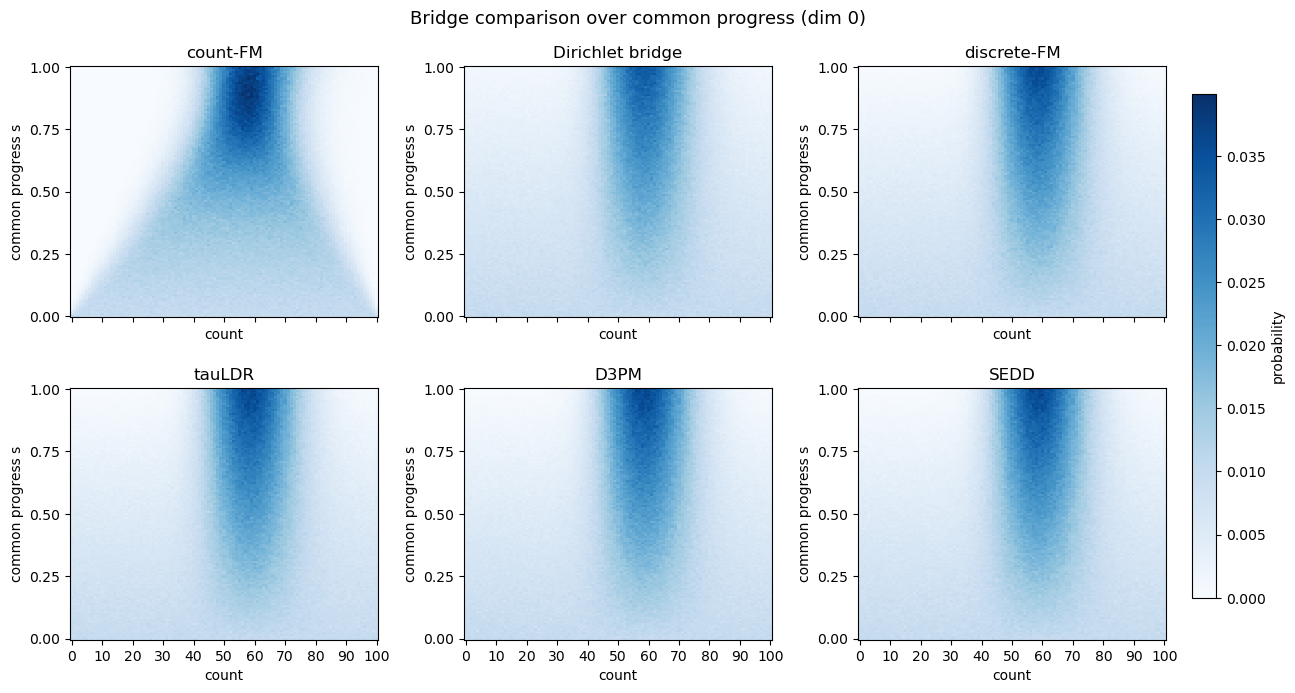

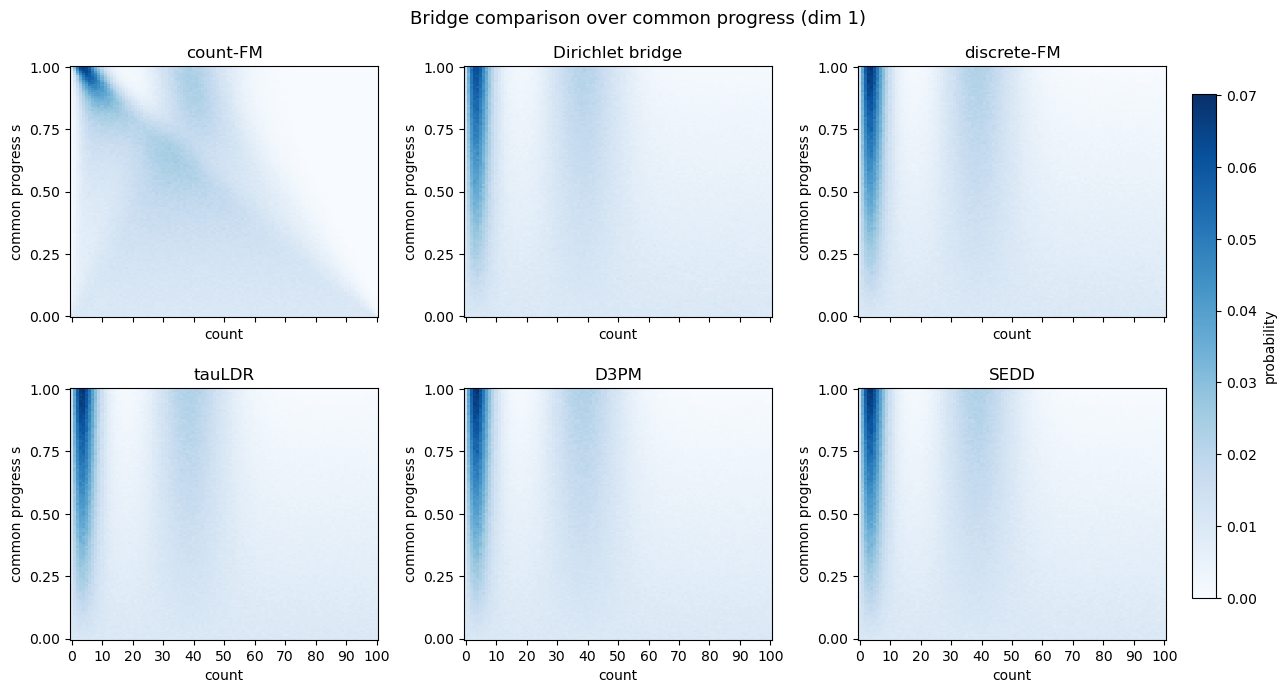

In [10]:
# for dim_idx in dims_to_plot:
#     fig, axes = plot_prob_grid(
#         P_dict=progress_prob_by_dim[dim_idx],
#         y_grid_dict=progress_grid_by_dim[dim_idx],
#         y_label="common progress s",
#         title=f"Bridge comparison over common progress ({dim_titles[dim_idx]})"
#     )
#     plt.show()

FIG_DIR = "figures_paper"
os.makedirs(FIG_DIR, exist_ok=True)

for dim_idx in dims_to_plot:
    fig, axes = plot_prob_grid(
        P_dict=progress_prob_by_dim[dim_idx],
        y_grid_dict=progress_grid_by_dim[dim_idx],
        y_label="common progress s",
        title=f"Bridge comparison over common progress ({dim_titles[dim_idx]})"
    )

    fig.savefig(
        os.path.join(FIG_DIR, f"prob_path_figure_s_dim{dim_idx}.pdf"),
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

## compact

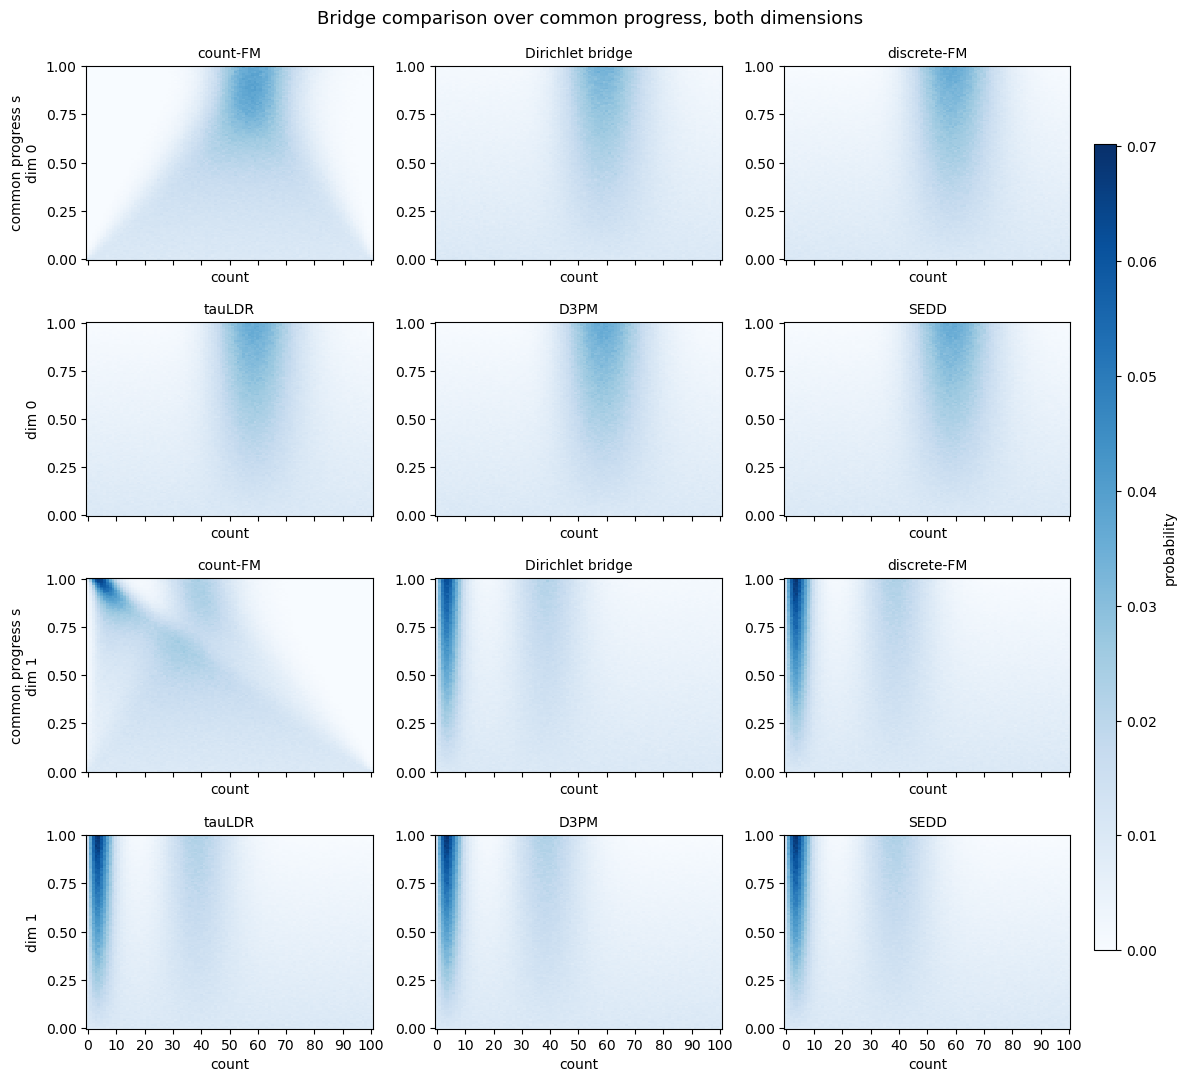

In [11]:
FIG_DIR = "figures_paper"
os.makedirs(FIG_DIR, exist_ok=True)

names = list(progress_prob_by_dim[dims_to_plot[0]].keys())
n = len(names)
ncols = 3
nrows_per_dim = int(np.ceil(n / ncols))
n_dim = len(dims_to_plot)

vmax = max(
    progress_prob_by_dim[dim_idx][name].max()
    for dim_idx in dims_to_plot
    for name in names
)
norm = Normalize(vmin=0.0, vmax=vmax)

fig, axes = plt.subplots(
    n_dim * nrows_per_dim,
    ncols,
    figsize=(4.0 * ncols, 2.8 * n_dim * nrows_per_dim),
    sharex=True,
    sharey=False,
)
axes = np.atleast_1d(axes).reshape(n_dim * nrows_per_dim, ncols)

im = None
for rdim, dim_idx in enumerate(dims_to_plot):
    P_dict = progress_prob_by_dim[dim_idx]
    y_grid_dict = progress_grid_by_dim[dim_idx]

    row_axes = axes[rdim * nrows_per_dim : (rdim + 1) * nrows_per_dim, :].ravel()

    for ax, name in zip(row_axes, names):
        P = P_dict[name]
        y_values = y_grid_dict[name]

        im = ax.imshow(
            P,
            origin="lower",
            aspect="auto",
            cmap="Blues",
            norm=norm,
            interpolation="nearest"
        )

        xticks = np.linspace(0, C_max, min(max_xticks, C_max + 1), dtype=int)
        xticks = np.unique(xticks)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks)

        T = P.shape[0]
        yticks = np.round(np.linspace(0, T - 1, 5)).astype(int)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{float(y_values[j]):.2f}" for j in yticks])

        ax.set_title(name, fontsize=10)
        ax.set_xlabel("count")

    for j in range(len(names), len(row_axes)):
        row_axes[j].axis("off")

    for rr in range(nrows_per_dim):
        ax_left = axes[rdim * nrows_per_dim + rr, 0]
        if rr == 0:
            ax_left.set_ylabel(f"common progress s\n{dim_titles[dim_idx]}")
        else:
            ax_left.set_ylabel(dim_titles[dim_idx])

fig.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.07,
    top=0.93,
    wspace=0.22,
    hspace=0.32,
)

cax = fig.add_axes([0.92, 0.14, 0.018, 0.72])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("probability")

fig.suptitle("Bridge comparison over common progress, both dimensions", y=0.98, fontsize=13)

fig.savefig(
    os.path.join(FIG_DIR, "prob_path_figure_s_both_dims.pdf"),
    format="pdf",
    bbox_inches="tight",
)

plt.show()
plt.close(fig)